In [31]:
#lasso reg
import pandas as pd
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso





In [32]:
inssurance_data=pd.read_csv("insurance.csv")
X=inssurance_data.drop(columns=["charges"])
Y=inssurance_data["charges"]

X= pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)
X["sex"]= X["sex"].map({"female": 1, "male": 0})
X["smoker"]= X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"]= X["age"]*X["smoker"]
X["bmi_smoker"]= X["bmi"]*X["smoker"]

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)

In [33]:
alpha_values= [0.001, 0.01, 0.1, 1.0,0.2, 5.0, 10.0 , 20 , 30 , 50 , 100]

for a in alpha_values:
    lasso_model= Lasso(alpha=a)
    lasso_model.fit(X_train, Y_train)
    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(Y_test, y_pred)
    print(f"Alpha: {a}, Mean Squared Error: {mse}")


Alpha: 0.001, Mean Squared Error: 20922599.871035974
Alpha: 0.01, Mean Squared Error: 20922527.326629896
Alpha: 0.1, Mean Squared Error: 20921803.69843139
Alpha: 1.0, Mean Squared Error: 20914832.635089148
Alpha: 0.2, Mean Squared Error: 20921006.729136672
Alpha: 5.0, Mean Squared Error: 20890881.000633504
Alpha: 10.0, Mean Squared Error: 20872844.794796687
Alpha: 20, Mean Squared Error: 20877828.53237883
Alpha: 30, Mean Squared Error: 20937537.13393977
Alpha: 50, Mean Squared Error: 21196929.869608898
Alpha: 100, Mean Squared Error: 22423172.68602322


<Axes: >

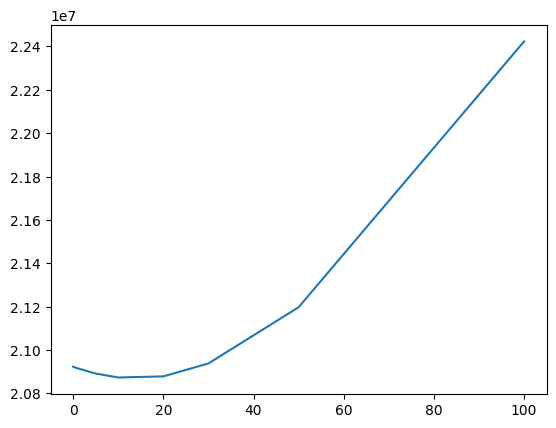

In [34]:
sns.lineplot(x=alpha_values, y=[mean_squared_error(Y_test, Lasso(alpha=a).fit(X_train, Y_train).predict(X_test)) for a in alpha_values])


In [ ]:
from sklearn.linear_model import LassoCV
alpha_values= [0.001, 0.01, 0.1, 1.0,0.2, 5.0, 10.0 , 20 , 30 , 50 , 100]
lasso_model= LassoCV(alphas=alpha_values, cv=5 , random_state=42 , max_iter=1000)
lasso_model.fit(X_train, Y_train)
print(f"Best alpha: {lasso_model.alpha_}")
y_pred=lasso_model.predict(X_test)
mse=mean_squared_error(Y_test, y_pred)
print(f"Mean Squared Error with best alpha: {mse}")
r2_score=lasso_model.score(X_test, Y_test)
print(f"R^2 Score with best alpha: {r2_score}")

Best alpha: 0.001
Mean Squared Error with best alpha: 20922599.871035974
R^2 Score with best alpha: 0.8652317499151698
